In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
from warnings import filterwarnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_validate
from sklearn.preprocessing import LabelEncoder
from textblob import Word, TextBlob
from wordcloud import WordCloud

In [4]:
filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [7]:
df = pd.read_csv("../data/Restaurant_Reviews.tsv",delimiter="\t")

In [8]:
#text preprocessing
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [10]:
df.shape

(1000, 2)

In [11]:
#Normalizing Case Folding
df['Review'] = df['Review'].str.lower()

In [12]:
:

df.head()



SyntaxError: invalid syntax (1457325697.py, line 1)

In [13]:


df.head()



,Review,Liked
0,wow... loved this place.,1
1,crust is not good.,0
2,not tasty and the texture was just nasty.,0
3,stopped by during the late may bank holiday of...,1
4,the selection on the menu was great and so wer...,1


In [14]:
#punctuations
df['Review'] = df['Review'].str.replace('[^\w\s]', '')

df['Review'] = df['Review'].str.replace('\d', '')



In [15]:
#stopwards
#It allows us to get rid of commonly used words.
sw = stopwords.words('english')
df['Review'] = df['Review'].apply(lambda x: " ".join(x for x in str(x).split() if x not in sw))

In [16]:
'''Rarewords

We drop words according to their frequencies.'''
drops = pd.Series(' '.join(df['Review']).split()).value_counts()[-250:]
df['Review'] = df['Review'].apply(lambda x: " ".join(x for x in x.split() if x not in drops))

In [21]:
#Tokenization

#break sentences into parts

df["Review"].apply(lambda x: TextBlob(x).words).head()



0                                  [wow, loved, place]
1                                        [crust, good]
2                              [tasty, texture, nasty]
3    [stopped, late, may, bank, holiday, rick, stev...
4                     [selection, menu, great, prices]
Name: Review, dtype: object

In [22]:


#Lemmatization / Stemming

#is the process of separating words by root

df['Review'] = df['Review'].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))



In [23]:
df["Review"].head()

0                                  wow... loved place.
1                                          crust good.
2                                 tasty texture nasty.
3    stopped late may bank holiday rick steve recom...
4                         selection menu great prices.
Name: Review, dtype: object

In [24]:
#    Text Visualization

#Calculate the term frequencies

tf = df["Review"].apply(lambda x: pd.value_counts(x.split(" "))).sum(axis=0).reset_index()


In [25]:


tf.columns = ["words", "tf"]
tf.head()



,words,tf
0,wow...,1.00
1,loved,10.00
2,place.,20.00
3,crust,2.00
4,good.,22.00


In [26]:


tf.shape



(2244, 2)

In [27]:
tf["words"].nunique()

2244

In [28]:
tf["tf"].describe([0.05, 0.10, 0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99]).T

count   2244.00
mean       2.46
std        4.73
min        1.00
5%         1.00
10%        1.00
25%        1.00
50%        1.00
75%        2.00
80%        3.00
90%        5.00
95%        8.00
99%       19.00
max       93.00
Name: tf, dtype: float64

In [29]:
tf.sort_values("tf", ascending = False)

,words,tf
113,food,93.00
77,place,82.00
143,good,62.00
19,great,57.00
42,service,57.00
...,...,...
1146,bird,1.00
1145,pile,1.00
1144,been-stepped-in-and-tracked-everywhere,1.00
1143,"smeared,",1.00


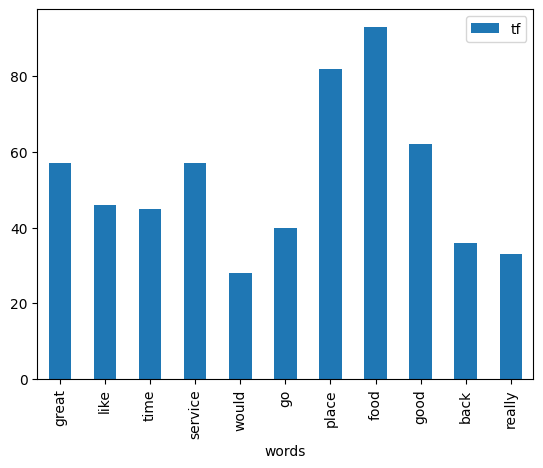

In [30]:
#barplot

tf[tf["tf"] > 25].plot.bar(x="words", y="tf")
plt.show()



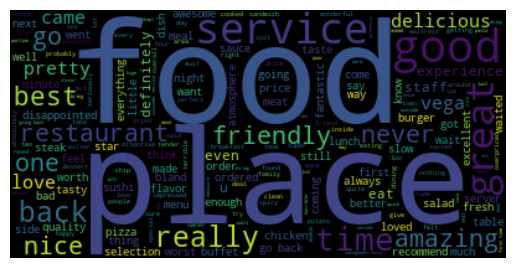

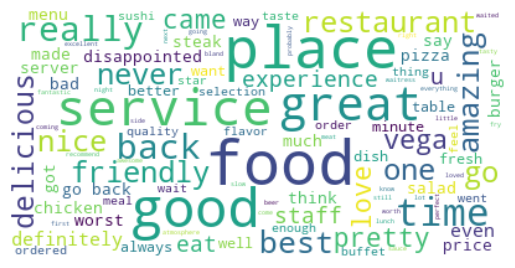

In [31]:


#Wordcloud

text = " ".join(i for i in df.Review)
wordcloud = WordCloud().generate(text)
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


wordcloud = WordCloud(max_font_size=50,
                      max_words=100,
                      background_color="white").generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

wordcloud.to_file("wordcloud.png")



In [33]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sayxp\AppData\Roaming\nltk_data...


True

In [34]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()
print(sia.polarity_scores("The food was awesome"))

{'neg': 0.0, 'neu': 0.423, 'pos': 0.577, 'compound': 0.6249}


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sayxp\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [35]:


df["Review"].apply(lambda x: x.upper())



0                                    WOW... LOVED PLACE.
1                                            CRUST GOOD.
2                                   TASTY TEXTURE NASTY.
3      STOPPED LATE MAY BANK HOLIDAY RICK STEVE RECOM...
4                           SELECTION MENU GREAT PRICES.
                             ...                        
995                   THINK FOOD FLAVOR TEXTURE LACKING.
996                             APPETITE INSTANTLY GONE.
997                     OVERALL IMPRESSED WOULD GO BACK.
998    WHOLE EXPERIENCE UNDERWHELMING, THINK GO NINJA...
999    THEN, WASTED ENOUGH LIFE THERE, POURED SALT WO...
Name: Review, Length: 1000, dtype: object

In [36]:
df["Review"][0:10].apply(lambda x: sia.polarity_scores(x))

0    {'neg': 0.0, 'neu': 0.339, 'pos': 0.661, 'comp...
1    {'neg': 0.0, 'neu': 0.256, 'pos': 0.744, 'comp...
2    {'neg': 0.643, 'neu': 0.357, 'pos': 0.0, 'comp...
3    {'neg': 0.123, 'neu': 0.452, 'pos': 0.426, 'co...
4    {'neg': 0.0, 'neu': 0.423, 'pos': 0.577, 'comp...
5    {'neg': 0.645, 'neu': 0.215, 'pos': 0.14, 'com...
6    {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...
7    {'neg': 0.0, 'neu': 0.63, 'pos': 0.37, 'compou...
8    {'neg': 0.0, 'neu': 0.328, 'pos': 0.672, 'comp...
9    {'neg': 0.0, 'neu': 0.196, 'pos': 0.804, 'comp...
Name: Review, dtype: object

In [37]:
df["polarity_score"] = df["Review"].apply(lambda x: sia.polarity_scores(x)["compound"])



In [38]:


df.head()




,Review,Liked,polarity_score
0,wow... loved place.,1,0.60
1,crust good.,0,0.44
2,tasty texture nasty.,0,-0.56
3,stopped late may bank holiday rick steve recom...,1,0.69
4,selection menu great prices.,1,0.62


In [40]:
#sentiment modeling


#Create the target

df["Review"][0:10].apply(lambda x: "pos" if sia.polarity_scores(x)["compound"] > 0 else "neg")



0    pos
1    pos
2    neg
3    pos
4    pos
5    neg
6    neg
7    pos
8    pos
9    pos
Name: Review, dtype: object

In [41]:
#Apply for all data

df["sentiment_label"] = df["Review"].apply(lambda x: "pos" if sia.polarity_scores(x)["compound"] > 0 else "neg")
df.head(20)



,Review,Liked,polarity_score,sentiment_label
0,wow... loved place.,1,0.60,pos
1,crust good.,0,0.44,pos
2,tasty texture nasty.,0,-0.56,neg
3,stopped late may bank holiday rick steve recom...,1,0.69,pos
4,selection menu great prices.,1,0.62,pos
5,getting angry want damn pho.,0,-0.69,neg
6,honeslty taste fresh.),0,0.00,neg
7,potato like rubber could tell made ahead time ...,0,0.57,pos
8,fry great too.,1,0.62,pos
9,great touch.,1,0.62,pos


In [42]:
#remmoving the punctuation marks
import string

df["Review"] = df["Review"].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))
df["Review"].head()

0                                      wow loved place
1                                           crust good
2                                  tasty texture nasty
3    stopped late may bank holiday rick steve recom...
4                          selection menu great prices
Name: Review, dtype: object

In [43]:


df.groupby("sentiment_label")["Liked"].mean()



sentiment_label
neg   0.22
pos   0.74
Name: Liked, dtype: float64

In [44]:
df["sentiment_label"] = LabelEncoder().fit_transform(df["sentiment_label"])

In [45]:
X = df["Review"]
y = df["sentiment_label"]

In [46]:
#Count Vectors

#converts text to a term count vector.

from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X_count = vectorizer.fit_transform(X)

vectorizer.get_feature_names()[10:15]
X_count.toarray()[10:15]



AttributeError: 'CountVectorizer' object has no attribute 'get_feature_names'

In [47]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_count = vectorizer.fit_transform(X)

vectorizer.get_feature_names_out()[10:15]
X_count.toarray()[10:15]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [48]:
#TF-IDF

#It is the weight factor calculated with the statistical method that shows the importance of a term in the document.
from sklearn.feature_extraction.text import TfidfVectorizer
tf_idf_word_vectorizer = TfidfVectorizer()
X_tf_idf_word = tf_idf_word_vectorizer.fit_transform(X)

In [49]:
tf_idf_ngram_vectorizer = TfidfVectorizer(ngram_range=(2, 3))
X_tf_idf_ngram = tf_idf_word_vectorizer.fit_transform(X)

In [50]:
#Logistic Regression

log_model = LogisticRegression().fit(X_tf_idf_word, y)

cross_val_score(log_model,
                X_tf_idf_word,
                y, scoring="accuracy",
                cv=5).mean()



0.833

In [51]:
random_review = pd.Series(df["Review"].sample(1).values)
random_review

0    complaints
dtype: object

In [52]:
new_comment = CountVectorizer().fit(X).transform(random_review)
log_model.predict(new_comment)

array([0])

In [53]:
rf_model = RandomForestClassifier().fit(X_count, y)
print(cross_val_score(rf_model, X_count, y, cv=5, n_jobs=-1).mean())

0.8460000000000001


In [54]:
#TF-IDF Word-Level

rf_model = RandomForestClassifier().fit(X_tf_idf_word, y)
print(cross_val_score(rf_model, X_tf_idf_word, y, cv=5, n_jobs=-1).mean())



0.8239999999999998


In [55]:
rf_model = RandomForestClassifier().fit(X_tf_idf_ngram, y)
print(cross_val_score(rf_model, X_tf_idf_ngram, y, cv=5, n_jobs=-1).mean())

0.8299999999999998


In [56]:
rf_model = RandomForestClassifier(random_state=17)

rf_params = {"max_depth": [5, 8, None],
             "max_features": [5, 7, "auto"],
             "min_samples_split": [2, 5, 8, 20],
             "n_estimators": [100, 200, 500]}

rf_best_grid = GridSearchCV(rf_model,
                            rf_params,
                            cv=5,
                            n_jobs=-1,
                            verbose=True).fit(X_count, y)

rf_best_grid.best_params_

rf_final = rf_model.set_params(**rf_best_grid.best_params_, random_state=17).fit(X_count, y)

cv_results = cross_validate(rf_final, X_count, y, cv=3, scoring=["accuracy", "f1", "roc_auc"])

cv_results['test_accuracy'].mean()
cv_results['test_f1'].mean()
cv_results['test_roc_auc'].mean()

Fitting 5 folds for each of 108 candidates, totalling 540 fits


0.9059531276034544